#### Lab - EDA Univariate Analysis: Diving into Amazon UK Product Insights
#### Objective: Explore the product listing dynamics on Amazon UK to extract actionable business insights. By understanding the distribution, central tendencies, and relationships of various product attributes, businesses can make more informed decisions on product positioning, pricing strategies, and inventory management.

#### Dataset: This lab utilizes the Amazon UK product dataset which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.

In [1]:
# Load data set:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy

# Replace with your actual file name
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")

# Quick check: see first 5 rows
df.head(5)


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


#### Part 1: Understanding Product Categories
#### Business Question: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

#### Frequency Tables:

#### 1. Generate a frequency table for the product category.


In [2]:
category_freq = df["category"].value_counts()
category_freq


category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Motorbike Chassis                            107
Alexa Built-In Devices                       107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

#### 2. Which are the top 5 most listed product categories?

In [3]:
top_5_categories = df["category"].value_counts().head(5)
top_5_categories



category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

The Top 5 most listed product categories are : Sports & Outdoors, Beauty, Handmade Clothing, Shoes & Accessories, Bath & Body and Birthday Gifts 

#### Visualizations:

#### 3. Display the distribution of products across different categories using a bar chart. If you face problems understanding the chart, do it for a subset of top categories.

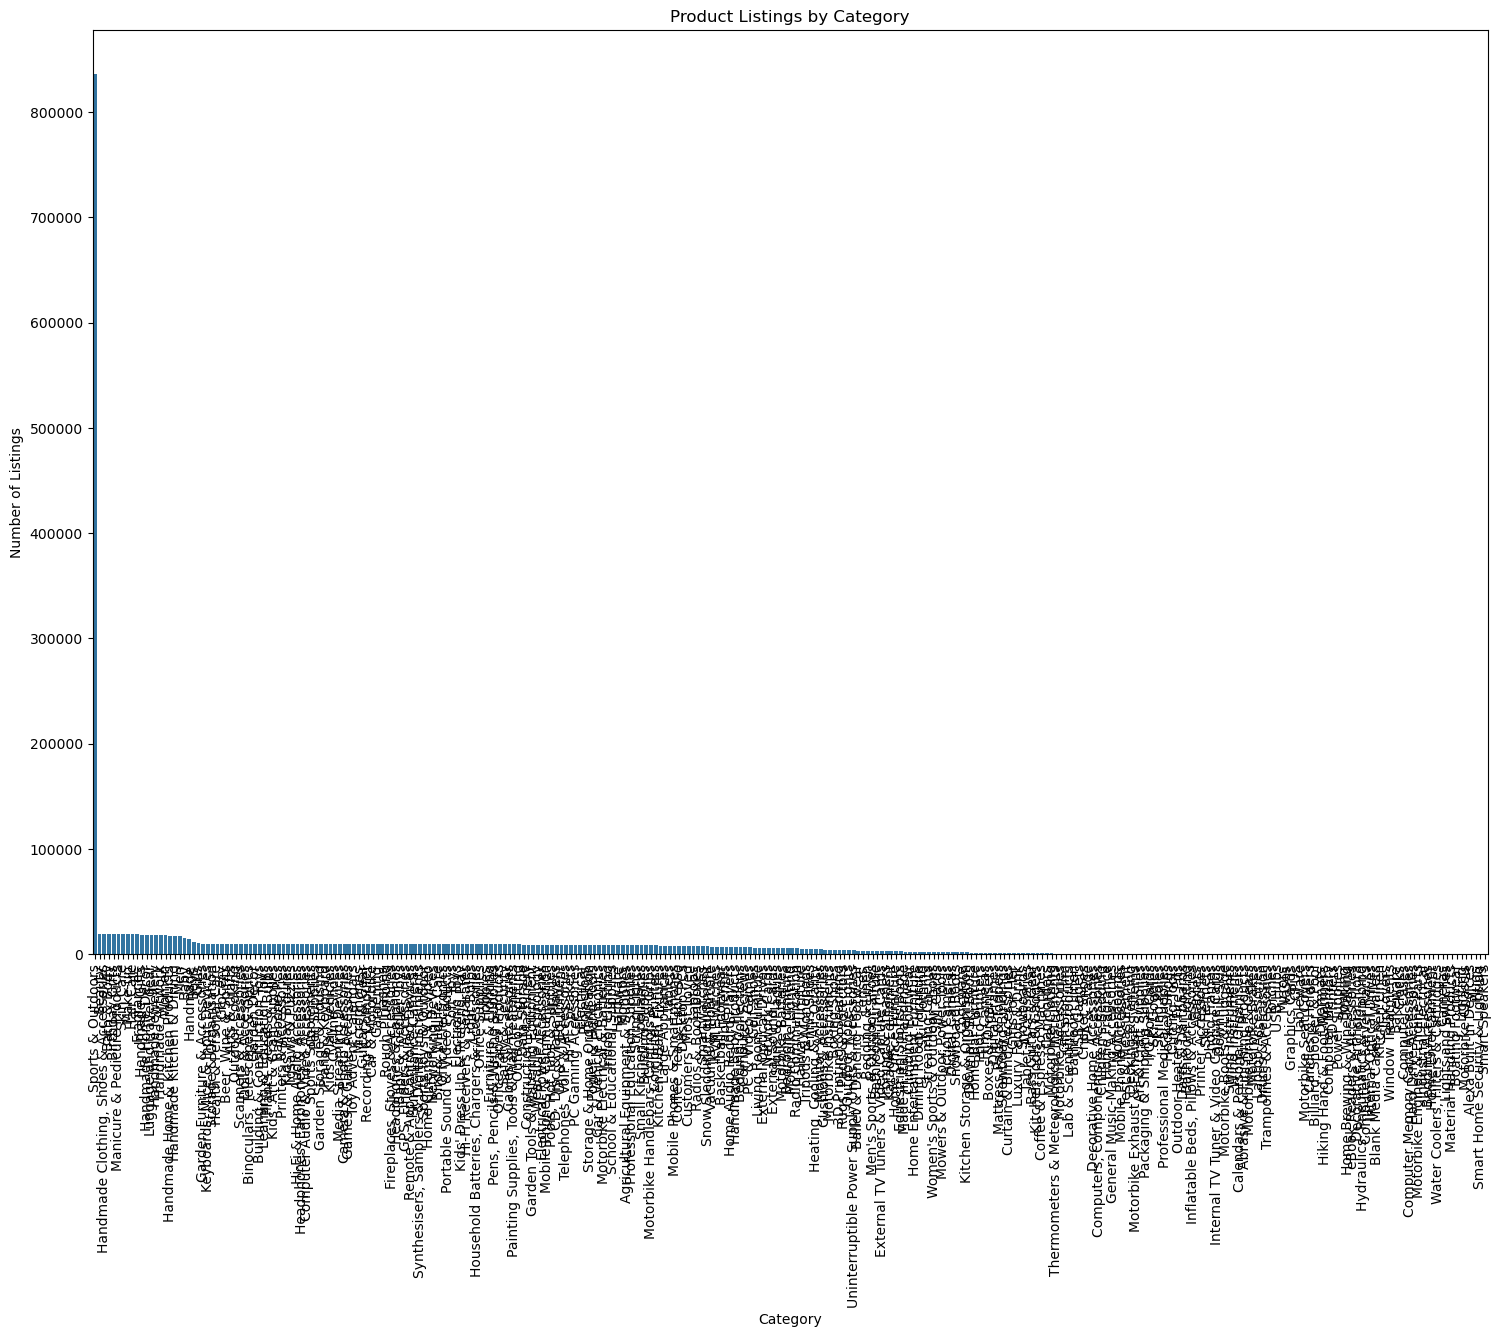

In [4]:
plt.figure(figsize=(18,12))
sns.barplot(x=category_freq.index, y=category_freq.values)
plt.xticks(rotation=90)
plt.title("Product Listings by Category")
plt.xlabel("Category")
plt.ylabel("Number of Listings")
plt.show()


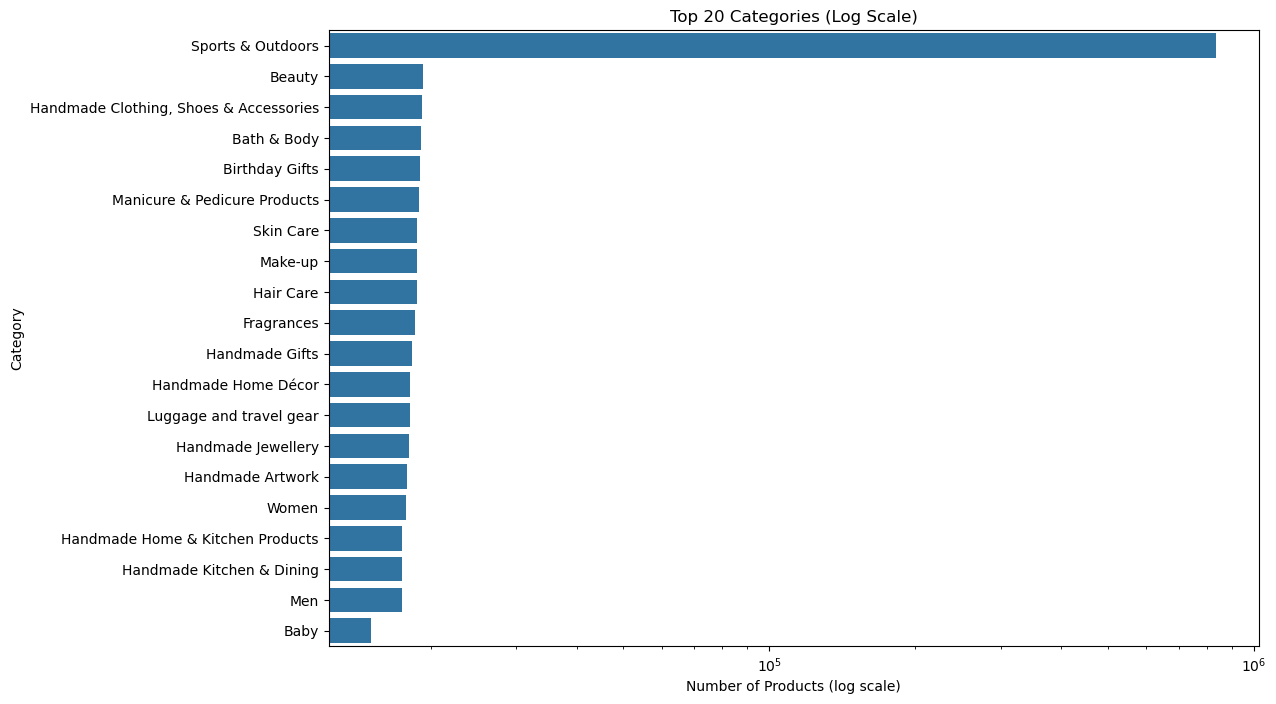

In [5]:
top_20 = df["category"].value_counts().head(20)

plt.figure(figsize=(12,8))
sns.barplot(x=top_20.values, y=top_20.index)

plt.xscale("log")

plt.title("Top 20 Categories (Log Scale)")
plt.xlabel("Number of Products (log scale)")

plt.ylabel("Category")

plt.show()

#### 4. For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

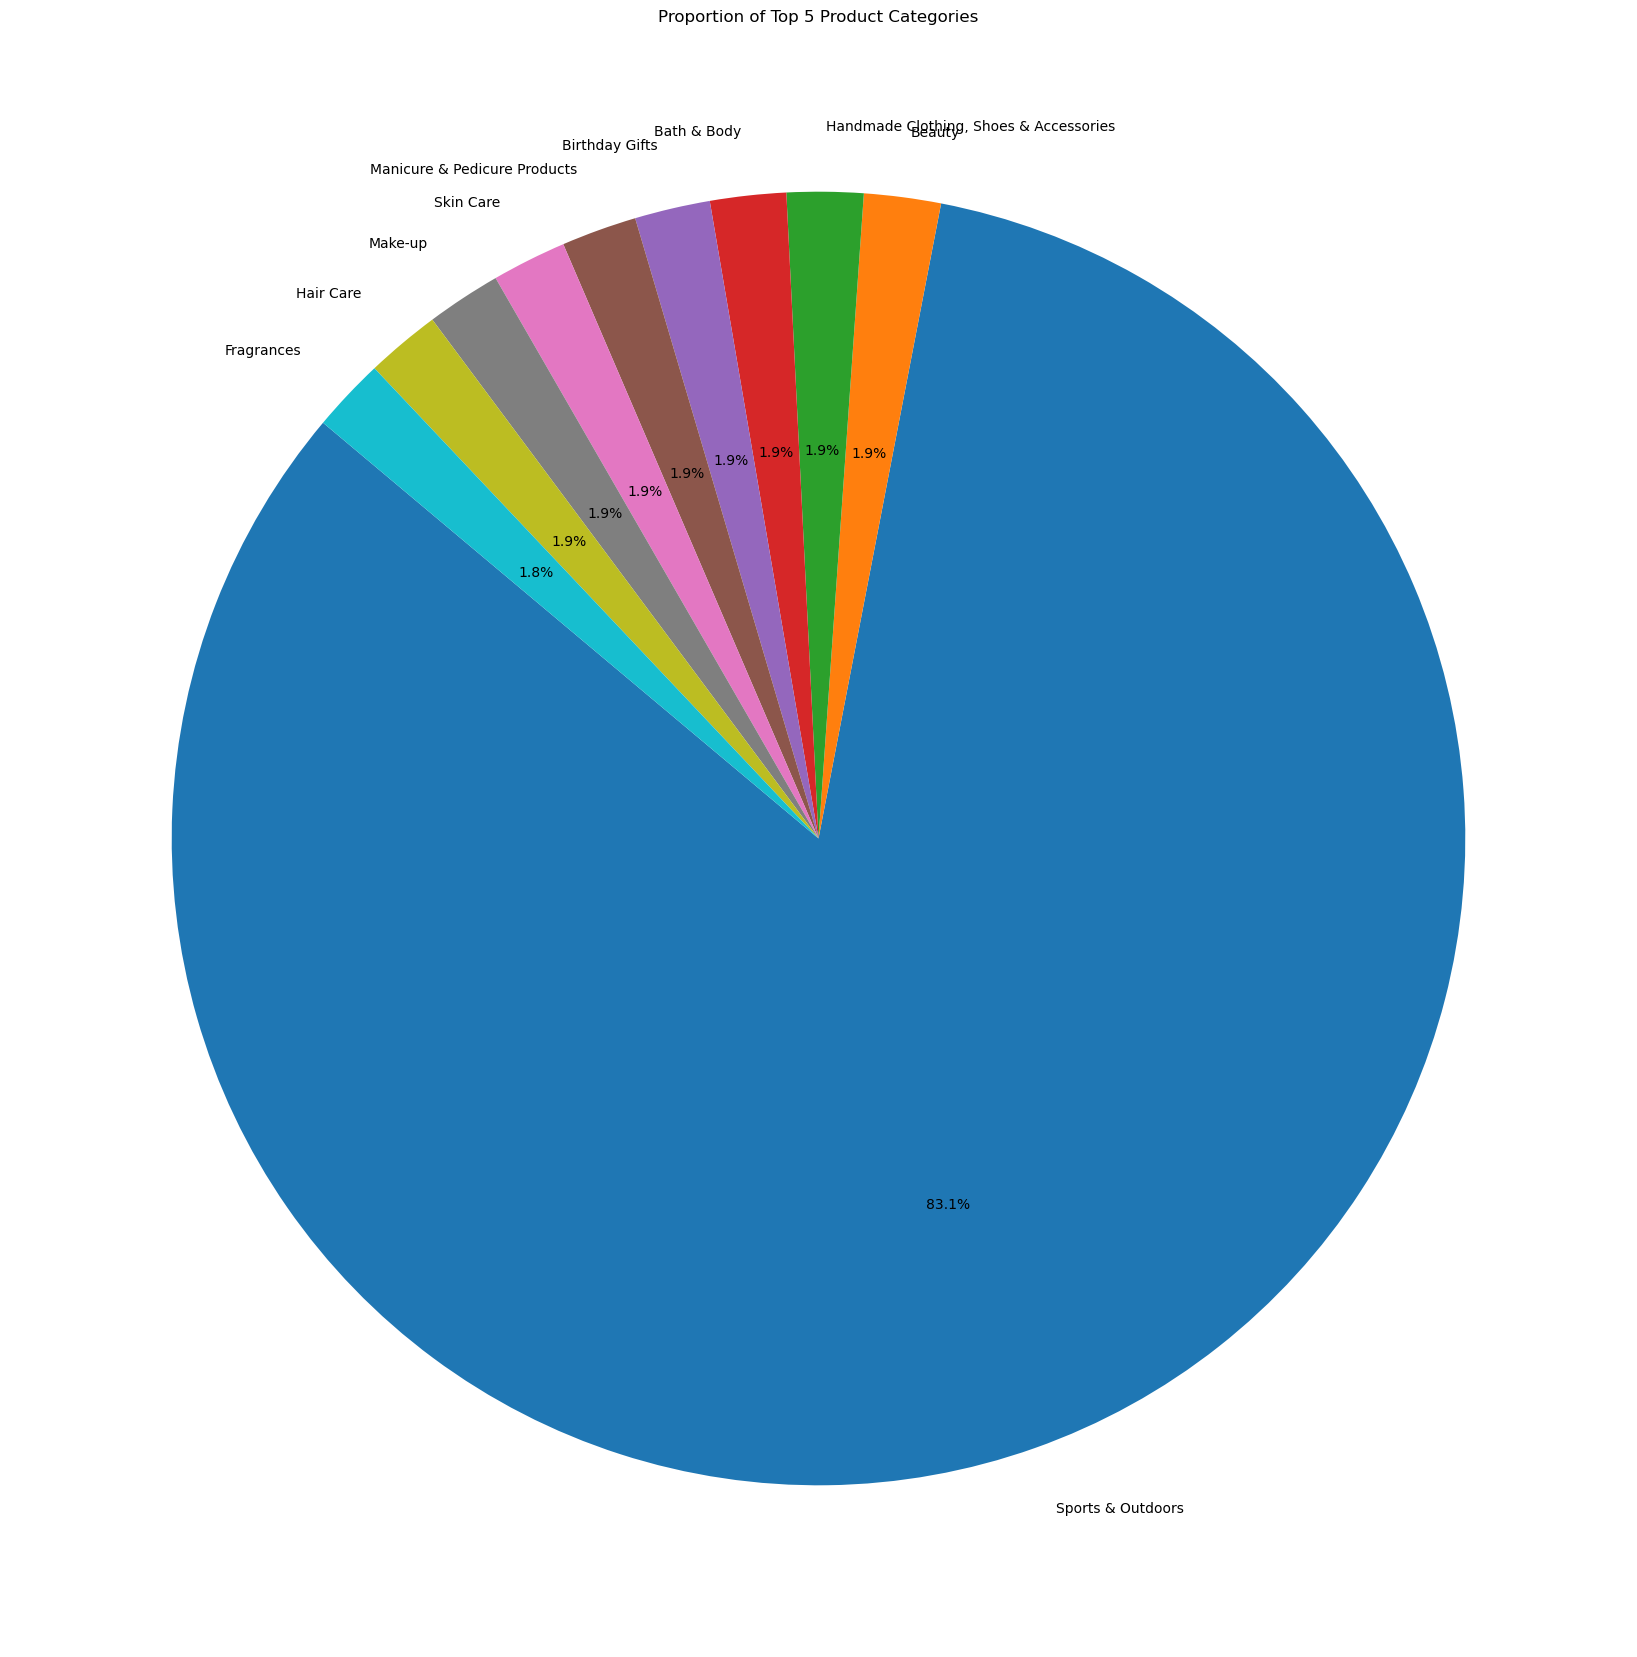

In [6]:
top10 = category_freq.head(10)

plt.figure(figsize=(24,21))
plt.pie(top10.values, labels=top10.index, autopct="%1.1f%%", startangle=140)
plt.title("Proportion of Top 5 Product Categories")
plt.show()


#### The Sports & Outdoors dominate the category with 83,1%. 

### Part 2: Delving into Product Pricing

#### Business Question: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

#### 1. Measures of Centrality:

#### 1.1 Calculate the mean, median, and mode for the price of products.
#### 1.2 What's the average price point of products listed? How does this compare with the most common price point (mode)?



In [7]:
# Checking price column for dtype
df["price"].head(5)




0    21.99
1    23.99
2    21.99
3    31.99
4    17.99
Name: price, dtype: float64

In [8]:
#### 1.1 Mean, Median, Mode

mean_price = df["price"].mean()
mean_price

np.float64(89.24380943923661)

In [9]:
median_price = df["price"].median()
median_price

np.float64(19.09)

In [10]:
mode_price = df["price"].mode()[0]
mode_price

np.float64(9.99)

In [11]:
#### 1.1 Mean, Median, Mode

print("Mean price:", mean_price)
print("Median price:", median_price)
print("Mode price:", mode_price)


Mean price: 89.24380943923661
Median price: 19.09
Mode price: 9.99


#### 2. Measures of Dispersion:

#### 2.1 Determine the variance, standard deviation, range, and interquartile range for product price.

In [12]:
variance_price = df["price"].var()
variance_price


np.float64(119445.48532254901)

In [13]:
std_price = df["price"].std()
std_price


np.float64(345.60886175349873)

In [14]:
range_price = df["price"].max() - df["price"].min()
range_price


np.float64(100000.0)

In [15]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

Q1, Q3, IQR


(np.float64(9.99), np.float64(45.99), np.float64(36.0))

In [16]:
print("Variance:", variance_price)
print("Standard Deviation:", std_price)
print("Range:", range_price)
print("IQR:", IQR)


Variance: 119445.48532254901
Standard Deviation: 345.60886175349873
Range: 100000.0
IQR: 36.0


2.2 How varied are the product prices? Are there any indicators of a significant spread in prices?

Variance = 119,445 is high due to std dev and range
std dev = 345.6 which indicates high priced items and high price differences
range = 100,000 indicates that the most expensive item is equal to 100,000
IQR = 36 indicates that most product are within price window price = 36 which is affordable.

#### 3. Visualizations:

#### 3.1 Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. If its hard to read these diagrams, think why this is, and explain how it could be solved..

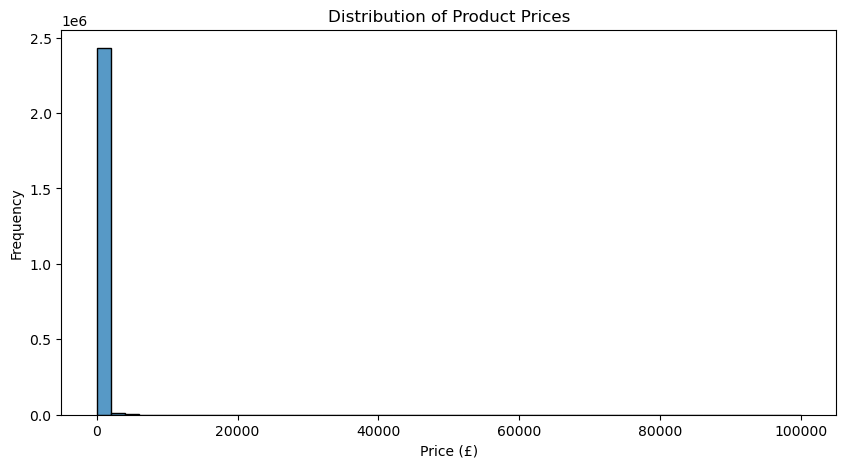

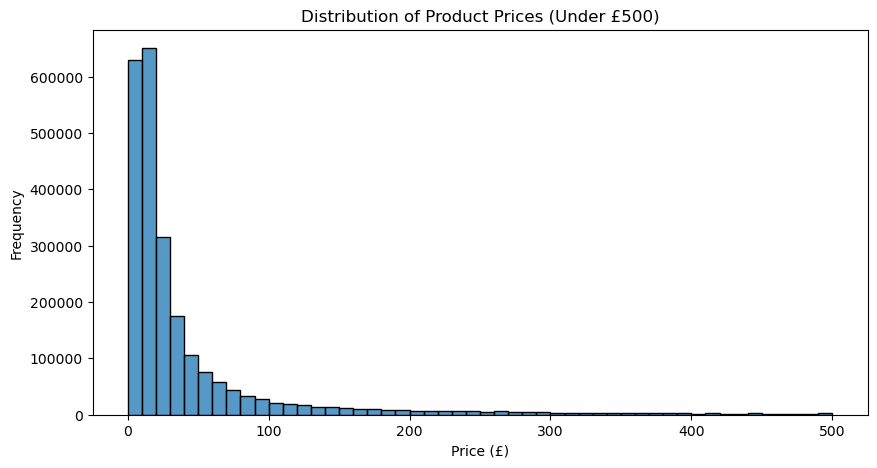

In [17]:
# 3.1 Histogram 
# Most products are cheap which will show most bar are on the left
# However the most expensive outliers are on the far right side

plt.figure(figsize=(10,5))
sns.histplot(df["price"], bins=50, kde=False)
plt.title("Distribution of Product Prices")
plt.xlabel("Price (£)")
plt.ylabel("Frequency")
plt.show()



# This removes extreme outliers and shows the “real” distribution.
# Most products fall under £500 and by removing extreme outliers makes the histogram readable.

plt.figure(figsize=(10,5))
sns.histplot(df[df["price"] < 500]["price"], bins=50)
plt.title("Distribution of Product Prices (Under £500)")
plt.xlabel("Price (£)")
plt.ylabel("Frequency")
plt.show()


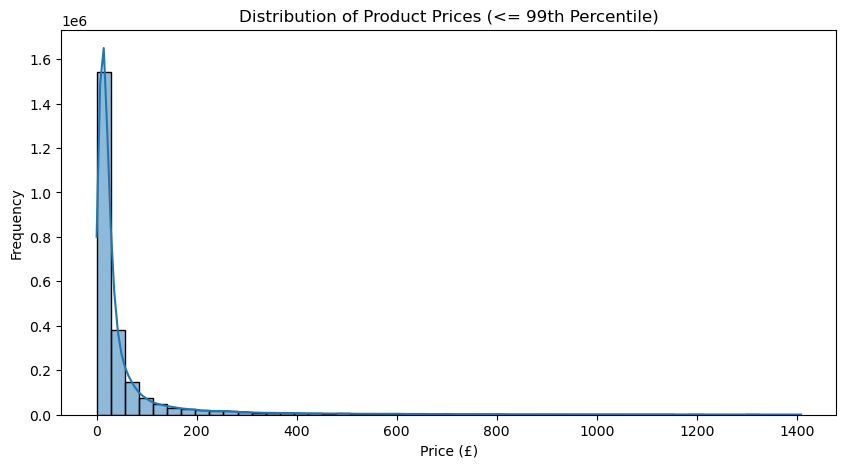

In [18]:
# Remove Extreme Outliers

p99 = df["price"].quantile(0.99)

plt.figure(figsize=(10,5))
sns.histplot(
    df[df["price"] <= p99]["price"],
    bins=50,
    kde=True
)

plt.title("Distribution of Product Prices (<= 99th Percentile)")
plt.xlabel("Price (£)")
plt.ylabel("Frequency")
plt.show()

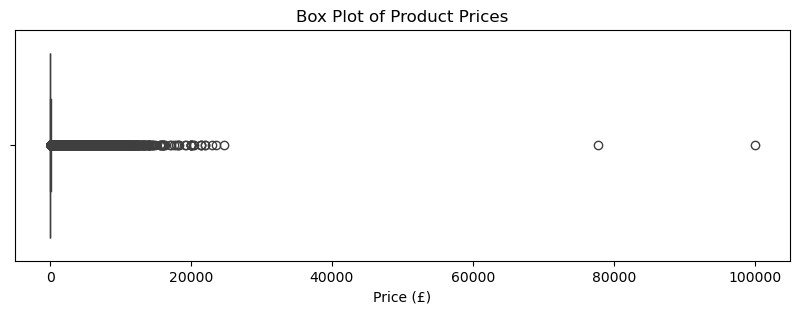

In [19]:
# 3.2 Box Plot 
# This removes extreme outliers and shows the distribution.
# Most products fall under £500 and by removing extreme outliers makes the histogram readable.


plt.figure(figsize=(10,3))
sns.boxplot(x=df["price"])
plt.title("Box Plot of Product Prices")
plt.xlabel("Price (£)")
plt.show()


### Part 3: Unpacking Product Ratings

#### Business Question: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

1. Measures of Centrality:

1.1 Calculate the mean, median, and mode for the rating of products.


In [20]:
# 1.1 Calculate the mean, median, and mode for the rating of products

mean_rating = df["stars"].mean()
mean_rating

np.float64(2.152836472966066)

In [21]:
median_rating = df["stars"].median()
median_rating

np.float64(0.0)

In [22]:
mode_rating = df["stars"].mode()[0]
mode_rating

np.float64(0.0)

In [23]:
print("Mean stars:", mean_rating)
print("Median stars:", median_rating)
print("Mode stars:", mode_rating)

Mean stars: 2.152836472966066
Median stars: 0.0
Mode stars: 0.0


1.2 How do customers generally rate products? Is there a common trend?
Median = 0 means that at least half of Amazon's products have a rating of 0 which indicates no rating or unrated items.
Mode = 0 means that most products have no customer rating at all which could be due to many new products.
Mean = 2.15 due to median and mode being equal to zero the mean has been pulled down, it does not reflect client's dissatisfaction.

#### 2. Measures of Dispersion:
#### 2.1 Determine the variance, standard deviation, and interquartile range for product rating.


In [24]:
# 2.1 Determine the variance, standard deviation, and interquartile range for product rating.
variance_rating = df["stars"].var()
variance_rating


np.float64(4.817434029796864)

In [25]:
std_rating = df["stars"].std()
std_rating

np.float64(2.194865378513421)

In [26]:
Q1 = df["stars"].quantile(0.25)
Q3 = df["stars"].quantile(0.75)
IQR_rating = Q3 - Q1

Q1, Q3, IQR_rating

(np.float64(0.0), np.float64(4.4), np.float64(4.4))

In [27]:
print("Variance:", variance_rating)
print("Standard Deviation:", std_rating)
print("IQR:", IQR_rating)

Variance: 4.817434029796864
Standard Deviation: 2.194865378513421
IQR: 4.4


2.2 Are the ratings consistent, or is there a wide variation in customer feedback?
Standard deviation = 2.19 means that customer feedback is highly scattered.
Variance = 4.82 means large spread
IQR = 4.4 means that the middle 50% of products range from 0 stars up to around 4.4 stars
Rating are not consistent due to many products have no rating (0 stars), mixed satisfaction and large spread. 

#### 3. Shape of the Distribution:

#### 3.1 Calculate the skewness and kurtosis for the rating column.

In [28]:
# 3.1 Calculate the skewness and kurtosis for the rating column.

from scipy.stats import skew, kurtosis

skewness = skew(df["stars"], nan_policy='omit')
kurt = kurtosis(df["stars"], nan_policy='omit')

print("Skewness:", skewness)
print("Kurtosis:", kurt)

Skewness: 0.08120730776283251
Kurtosis: -1.9260046425498396


3.2 Are the ratings normally distributed, or do they lean towards higher or lower values?
The ratings do not strongly lean toward either higher or lower values (skewness ≈ 0). However, the negative kurtosis indicates that ratings are more evenly spread out and less peaked than a normal distribution. Therefore, the ratings are relatively balanced but not normally distributed.

#### 4. Visualizations:

#### 4.1 Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?


In [29]:
df["stars"].head()

0    4.7
1    4.7
2    4.7
3    4.7
4    4.6
Name: stars, dtype: float64

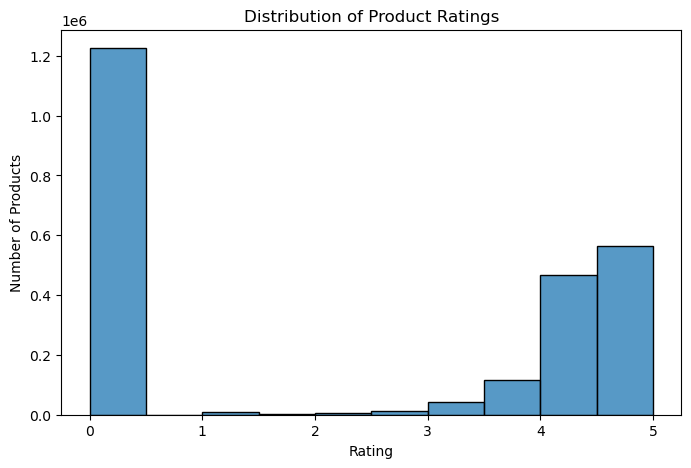

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df["stars"], bins=10)
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.show()

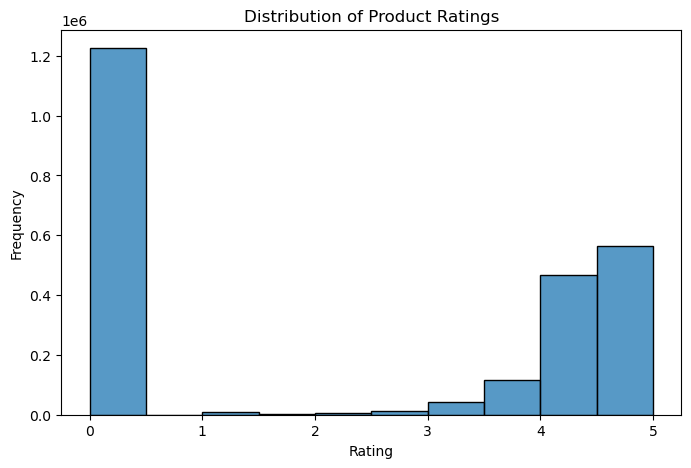

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df["stars"], bins=[0,0.5,1,1.5,2,2.5,3,3.5,4,4.5,5])
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

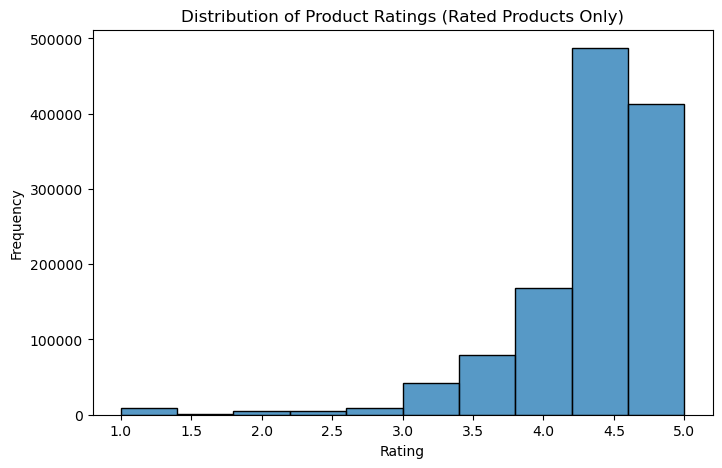

In [32]:
rated_products = df[df["stars"] > 0]
plt.figure(figsize=(8,5))
sns.histplot(rated_products["stars"], bins=10)
plt.title("Distribution of Product Ratings (Rated Products Only)")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

Most common rating are concentrated between 4.0 and 4.8 and rating. Between 2.0 and 4.0 ratings are mixed and between zero and 1 ratings might be due to new unrated items. 